# 🔢 MNIST 手写数字识别 — 从零搭建 CNN 多分类模型

**目标**：基于 MNIST 手写数字数据集，使用 TensorFlow/Keras 从零搭建卷积神经网络（CNN），实现对手写数字 0-9 的分类识别。

**数据集**：

| 属性 | 说明 |
|------|------|
| 文件名 | `mnist/mnist.pkl.gz` |
| 总样本数 | 70,000 张 |
| 图像尺寸 | 28×28 像素，灰度图（单通道） |
| 类别 | 0 ~ 9 共 10 个数字 |
| 数据格式 | 已预归一化到 [0, 1] 范围 |
| 原始划分 | 训练 50,000 / 验证 10,000 / 测试 10,000 |

> ⚠️ **重要提示**：该数据集**已经预归一化**，像素值在 [0, 1] 范围内。**不要再除以 255！** 否则会变成 [0, 0.004] 的极小值，导致模型无法正常训练。

---

## 📋 目录

1. 环境准备
2. 数据加载与探索
3. 数据预处理
4. 数据可视化
5. 🧠 卷积神经网络工作原理详解
   - 5.1 为什么用 CNN 而不是全连接？
   - 5.2 卷积层（Convolutional Layer）
   - 5.3 池化层（Pooling Layer）
   - 5.4 全连接层与 Dropout
   - 5.5 Softmax 输出层
6. 模型搭建与编译
7. 模型训练
8. 模型评估
9. 预测验证与错误分析
10. 保存模型（含 ONNX 转换）
11. 🔧 调参实验区
12. 🤔 思考题

---
## 1. 环境准备

导入本项目所需的所有库。每个库的作用见注释。

In [106]:
# ========== 1. 环境准备 ==========

# — 基础库 —
import numpy as np                # 数值计算，矩阵操作
import matplotlib.pyplot as plt   # 绘图可视化
import pickle, gzip, os           # 读取 .pkl.gz 压缩数据文件

# — 中文字体设置（防止图表中文乱码）—
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

# — 机器学习工具 —
from sklearn.model_selection import train_test_split  # 数据集划分
from sklearn.metrics import confusion_matrix, classification_report  # 评估指标
import seaborn as sns              # 热力图（混淆矩阵）

# — TensorFlow / Keras —
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# — 固定随机种子，确保实验结果可复现 —
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow 版本: {tf.__version__}")
print(f"NumPy 版本: {np.__version__}")

TensorFlow 版本: 2.21.0
NumPy 版本: 2.2.6


---
## 2. 数据加载与探索

MNIST 数据集存储在 `mnist/mnist.pkl.gz` 文件中。这是一个 gzip 压缩的 pickle 序列化文件，
解压后得到三个元组：`(training_data, validation_data, test_data)`。

每个元组包含 `(图像数据, 标签)`，图像数据是 784 维的扁平向量（需要 reshape 为 28×28）。

In [107]:
# ========== 2.1 加载数据 ==========

# 构建数据文件路径（当前目录的上级 mnist 文件夹）
data_path = os.path.join('..', 'mnist', 'mnist.pkl.gz')
print(f"数据路径: {os.path.abspath(data_path)}")

# 使用 gzip 打开压缩文件，pickle 反序列化
with gzip.open(data_path, 'rb') as f:
    # encoding='latin1' 是为了兼容 Python 2 生成的 pickle 文件
    training_data, validation_data, test_data = pickle.load(f, encoding='latin1')

# 解包：每个变量包含 (图像数组, 标签数组)
X_train_raw, y_train_raw = training_data    # 训练集
X_val_raw,   y_val_raw   = validation_data  # 验证集
X_test_raw,  y_test_raw  = test_data        # 测试集

# — 查看数据基本信息 —
print(f"\n{'='*50}")
print(f"训练集样本数: {len(X_train_raw):,}")
print(f"验证集样本数: {len(X_val_raw):,}")
print(f"测试集样本数: {len(X_test_raw):,}")
print(f"\n原始数据形状（扁平向量）: {X_train_raw.shape}")
print(f"  第 1 维 = 样本数 (50,000)")
print(f"  第 2 维 = 像素数 (28×28 = 784)")
print(f"\n标签形状: {y_train_raw.shape}")
print(f"标签示例（前 10 个）: {y_train_raw[:10]}")

数据路径: d:\Desktop\School Course\Grade 3-2\人工智能\code\神经网络回归预测与分类\mnist\mnist.pkl.gz

训练集样本数: 50,000
验证集样本数: 10,000
测试集样本数: 10,000

原始数据形状（扁平向量）: (50000, 784)
  第 1 维 = 样本数 (50,000)
  第 2 维 = 像素数 (28×28 = 784)

标签形状: (50000,)
标签示例（前 10 个）: [5 0 4 1 9 2 1 3 1 4]


In [108]:
# ========== 2.2 检查数据值域 ==========

# ⚠️ 关键检查：确认数据是否已经归一化
print(f"像素值范围: [{X_train_raw.min():.6f}, {X_train_raw.max():.6f}]")
print(f"像素均值: {X_train_raw.mean():.4f}")
print(f"零值占比: {(X_train_raw == 0).mean()*100:.1f}%")
print(f"\n结论: ", end="")
if X_train_raw.max() <= 1.0:
    print("✅ 数据已在 [0, 1] 范围，无需额外归一化！")
else:
    print("⚠️ 数据在 [0, 255] 范围，需要除以 255 进行归一化。")

像素值范围: [0.000000, 0.996094]
像素均值: 0.1304
零值占比: 80.9%

结论: ✅ 数据已在 [0, 1] 范围，无需额外归一化！


In [109]:
# ========== 2.3 标签分布 ==========

# 查看每个数字类别的样本数量，判断数据是否均衡
labels, counts = np.unique(y_train_raw, return_counts=True)
print("训练集类别分布:")
print(f"{'数字':<6} {'样本数':<8} {'占比':<8} {'分布图'}")
print("-" * 50)
for label, count in zip(labels, counts):
    pct = count / len(y_train_raw) * 100
    bar = '█' * int(count / 200)  # 每 200 个样本一个方块
    print(f"{label:<6} {count:<8} {pct:<8.1f}% {bar}")

print(f"\n类别均衡性: 最多 {counts.max()}, 最少 {counts.min()}")
print(f"极差比值: {counts.max()/counts.min():.2f} (理想值 ≈ 1.0)")

训练集类别分布:
数字     样本数      占比       分布图
--------------------------------------------------
0      4932     9.9     % ████████████████████████
1      5678     11.4    % ████████████████████████████
2      4968     9.9     % ████████████████████████
3      5101     10.2    % █████████████████████████
4      4859     9.7     % ████████████████████████
5      4506     9.0     % ██████████████████████
6      4951     9.9     % ████████████████████████
7      5175     10.3    % █████████████████████████
8      4842     9.7     % ████████████████████████
9      4988     10.0    % ████████████████████████

类别均衡性: 最多 5678, 最少 4506
极差比值: 1.26 (理想值 ≈ 1.0)


> **❓ 思考**：为什么需要关注类别是否均衡？  
> **答**：如果某些类别的样本远多于其他类别，模型会偏向预测多数类，
> 导致少数类的识别率很低。MNIST 的类别分布大致均匀，不需要额外处理。

---
## 3. 数据预处理

原始数据是 784 维扁平向量，需要还原为 28×28 的图像格式。同时合并训练集和验证集，
用 `train_test_split` 重新按 9:1 划分，保证数据分布的随机性。

| 步骤 | 操作 | 输入形状 | 输出形状 | 说明 |
|------|------|----------|----------|------|
| ① reshape | 扁平 → 2D 图像 | (N, 784) | (N, 28, 28, 1) | 恢复空间结构，1 表示灰度单通道 |
| ② astype | int → float32 | - | - | Keras 需要浮点类型输入 |
| ③ 合并 | 训练+验证拼接 | - | (60000, 28, 28, 1) | 扩大数据池 |
| ④ 重划分 | 9:1 随机分割 | - | (54000, 6000) | 用 sklearn 确保分层抽样 |

> ⚠️ **不需要除以 255**：第 2 节已验证数据已在 [0, 1] 范围。

In [110]:
# ========== 3. 数据预处理 ==========

# 3.1 reshape: 将 784 维向量还原为 28×28×1 的图像格式
# -1 表示"自动计算该维度"；28,28,1 表示高28、宽28、单通道（灰度）
X_train_raw = X_train_raw.reshape(-1, 28, 28, 1)
X_val_raw   = X_val_raw.reshape(-1, 28, 28, 1)
X_test_raw  = X_test_raw.reshape(-1, 28, 28, 1)

# 3.2 类型转换：转为 float32（GPU 运算的标准浮点格式）
X_train_raw = X_train_raw.astype('float32')
X_val_raw   = X_val_raw.astype('float32')
X_test_raw  = X_test_raw.astype('float32')

# 标签也转为 numpy 数组
y_train_raw = np.array(y_train_raw)
y_val_raw   = np.array(y_val_raw)
y_test_raw  = np.array(y_test_raw)

# 3.3 合并训练集和验证集
X_all = np.concatenate([X_train_raw, X_val_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_val_raw], axis=0)

# 3.4 重新按 9:1 随机划分
# stratify=y_all：确保划分后各类别比例与原始数据一致（分层抽样）
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.1, random_state=42, stratify=y_all
)
X_test, y_test = X_test_raw, y_test_raw

# — 打印预处理结果 —
print(f"预处理后数据形状:")
print(f"  训练集: X={X_train.shape}, y={y_train.shape}")
print(f"  验证集: X={X_valid.shape}, y={y_valid.shape}")
print(f"  测试集: X={X_test.shape}, y={y_test.shape}")
print(f"\n值域检查: [{X_train.min():.2f}, {X_train.max():.2f}]  ← 仍在 [0,1] 范围内")

预处理后数据形状:
  训练集: X=(54000, 28, 28, 1), y=(54000,)
  验证集: X=(6000, 28, 28, 1), y=(6000,)
  测试集: X=(10000, 28, 28, 1), y=(10000,)

值域检查: [0.00, 1.00]  ← 仍在 [0,1] 范围内


> **❓ 思考**：为什么需要把训练集和验证集合并再重新划分？  
> **答**：原始数据的训练/验证划分顺序可能是固定的（比如按采集时间），可能引入偏差。
> 合并后随机重分可以打乱顺序，让验证集更具代表性。`stratify` 参数保证各类别
> 在训练集和验证集中的比例一致，避免某类数字全部被分到验证集。

---
## 4. 数据可视化

在训练模型之前，先直观感受一下数据的样子。随机抽取 25 张图片用 5×5 网格展示。

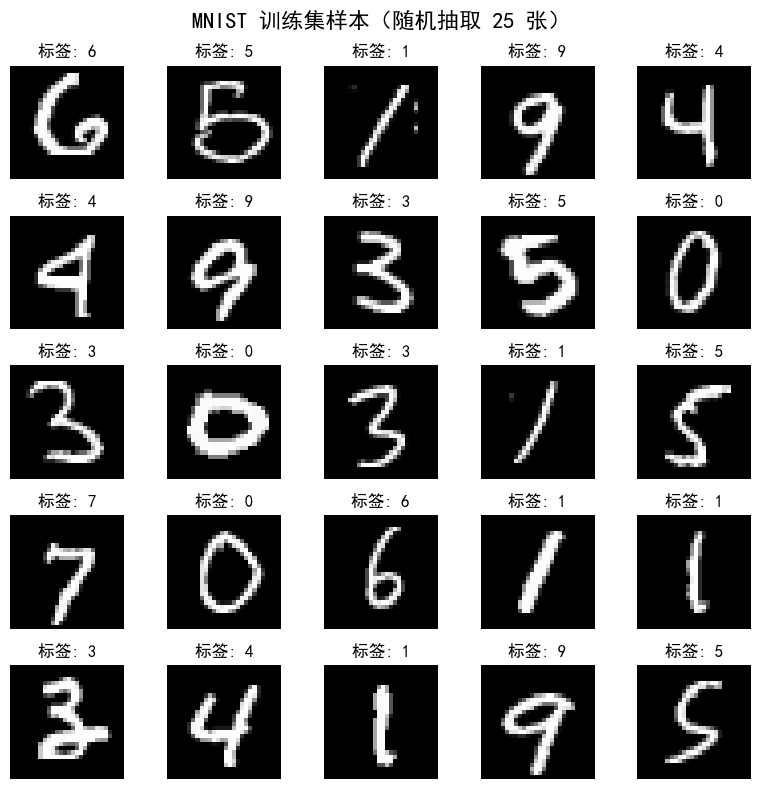

In [111]:
# ========== 4. 数据可视化 ==========

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
fig.suptitle('MNIST 训练集样本（随机抽取 25 张）', fontsize=16, fontweight='bold')

# 从训练集中随机选 25 个不重复的索引
indices = np.random.choice(len(X_train), 25, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    # reshape(28,28) 去掉通道维度用于 imshow；cmap='gray' 使用灰度色图
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'标签: {y_train[idx]}', fontsize=12)
    ax.axis('off')  # 隐藏坐标轴

plt.tight_layout()
plt.show()

---
## 5. 🧠 卷积神经网络（CNN）工作原理详解

在写代码之前，先理解 CNN 为什么适合图像任务，以及每一层在做什么。

### 5.1 为什么用 CNN 而不是全连接神经网络？

| 对比维度 | 全连接网络 (Dense) | 卷积神经网络 (CNN) |
|----------|-------------------|---------------------|
| 输入方式 | 将 28×28=784 像素展开为 1D 向量 | 保留 28×28 的 2D 空间结构 |
| 参数数量 | 784×128 ≈ 10 万（仅第一层） | 3×3×32 ≈ 288（每个卷积核） |
| 空间信息 | **丢失** — 相邻像素被拆散 | **保留** — 卷积核在 2D 空间滑动 |
| 平移不变性 | 无 — 数字移动一个像素就需要全新参数 | **有** — 同一个卷积核扫过整张图 |
| 局部特征 | 无法专门捕捉 | 每个卷积核专注一个局部模式（边缘/纹理） |

> **核心优势**：CNN 的**参数共享**（同一个卷积核扫过全图）和**局部感受野**（每次只看一小块区域）
> 使得它用极少的参数就能捕捉图像中的空间模式。

> **🔑 参数量对比**：  
> 全连接第一层: 784 像素 × 128 神经元 = **100,352** 参数  
> 卷积第一层: 32 个卷积核 × (3×3 + 1 偏置) = **320** 参数  
> CNN 参数量仅为全连接的 **0.3%**，却能提取更丰富的特征！

### 5.2 卷积层（Conv2D）— 提取局部特征

卷积层是 CNN 的核心。一个**卷积核（filter/kernel）**就是一个小矩阵（如 3×3），
在输入图像上**滑动**，每次计算"卷积核权重 × 对应区域像素"的和，生成一个**特征图（feature map）**。

```
输入图像 28×28          卷积核 3×3              输出特征图 26×26
┌──────────────┐       ┌─────┐       ┌──────────────────┐
│ 0 0 0 1 ... │       │ 1 0 -1│      │ 检测到边缘！     │
│ 0 0 1 1 ... │  →   │ 1 0 -1│  →   │ 输出值较大处=    │
│ 0 1 1 1 ... │       │ 1 0 -1│      │ 有竖直边缘       │
│ 1 1 1 1 ... │       └─────┘       └──────────────────┘
│ ...         │
└──────────────┘        ← 这个核检测"竖直边缘"
```

> **为什么输出是 26×26？**  
> 3×3 卷积核在 28×28 图上滑动时，不能在边界外操作，所以每边损失 1 个像素。  
> 输出尺寸 = 28 - 3 + 1 = 26。这个规律是：**输出 = 输入 - 卷积核 + 1**。

**多个卷积核 → 多个特征图**：  
- 第 1 层 32 个卷积核 → 32 个不同的特征图，分别检测**边缘、纹理、角点**等低级特征  
- 第 2 层 64 个卷积核 → 64 个特征图，在前一层的基础上检测**更复杂的形状组合**  

**ReLU 激活函数**：卷积之后接 ReLU（$f(x) = \max(0, x)$），作用是：  
- **引入非线性**：没有激活函数，多层卷积等价于一层线性变换  
- **计算简单**：只需判断是否大于 0  
- **缓解梯度消失**：正区间的导数恒为 1

### 5.3 池化层（MaxPooling2D）— 降维压缩

池化层在特征图上取**局部最大值**（或平均值），将特征图尺寸**减半**，同时保留最重要的特征。

```
输入 26×26                       输出 13×13
┌──────────────────┐            ┌──────────────┐
│ 3  1  2  5 ...  │  2×2 窗口  │ 3  5  ...    │  ← 每个窗口取最大值
│ 0  2  1  7 ...  │  → 取最大 →│ 4  8  ...    │
│ 4  1  2  8 ...  │            │ ...          │
│ 2  1  3  4 ...  │            └──────────────┘
└──────────────────┘
```

> **池化的三大作用**：  
> 1. **降维减参**：特征图变小 → 后续层的参数量大幅减少 → 防止过拟合  
> 2. **平移不变性**：数字稍微移动，最大值仍然被保留  
> 3. **扩大感受野**：经过两次池化后，一个像素对应原始图像中 8×8 的区域

### 5.4 全连接层（Dense）与 Dropout

经过两层卷积+池化后，特征图变成 5×5×64 = 1600 维。用 `Flatten` 展平为 1D 向量，
送入全连接层进行分类。

- **全连接层**：每个神经元连接上一层的所有神经元，综合所有特征进行高层推理
- **Dropout(0.5)**：训练时**随机丢弃 50% 的神经元**，每个 batch 丢弃不同的神经元

> **为什么需要 Dropout？**  
> Dropout 是一种**正则化**技术，防止过拟合。它的本质是：  
> 1. 每次训练只使用一半的神经元 → 相当于训练了多个不同的"子网络"  
> 2. 预测时所有神经元都参与 → 相当于对多个子网络的预测取平均（集成学习效果）  
> 3. 神经元不能依赖特定同伴的存在 → 被迫学习更鲁棒、更独立的特征

### 5.5 Softmax 输出层

最后一层 10 个神经元，通过 **Softmax** 函数将输出转为概率分布：

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=0}^{9} e^{z_j}}$$

- 10 个输出值之和 = 1（构成合法的概率分布）
- 每个值代表模型认为该数字是第 $i$ 类的概率
- 取概率最大的索引作为最终预测结果

> **为什么用 Softmax 而不是 Sigmoid？**  
> Sigmoid 把每个输出独立压缩到 (0,1)，**不保证总和为 1**。  
> Softmax 的输出互相竞争——一个变大其他的就会变小，非常适合"互斥多分类"。

---
## 6. 模型搭建与编译

根据上面的理论，搭建以下 CNN 架构：

| 层 | 类型 | 核心参数 | 输出形状 | 参数量 | 作用 |
|----|------|----------|----------|--------|------|
| 1 | Conv2D | 32核, 3×3, ReLU | (26, 26, 32) | 320 | 提取低级特征（边缘、纹理）|
| 2 | MaxPool2D | 2×2 | (13, 13, 32) | 0 | 降维，保留主要特征 |
| 3 | Conv2D | 64核, 3×3, ReLU | (11, 11, 64) | 18,496 | 组合低级特征为高级形状 |
| 4 | MaxPool2D | 2×2 | (5, 5, 64) | 0 | 再次降维 |
| 5 | Flatten | - | 1600 | 0 | 展平为 1D 向量 |
| 6 | Dense | 128, ReLU | 128 | 204,928 | 综合所有特征 |
| 7 | Dropout | 0.5 | 128 | 0 | 随机丢弃，防止过拟合 |
| 8 | Dense | 10, Softmax | 10 | 1,290 | 输出 10 类概率 |
| **合计** | | | | **225,034** | |

> **参数量最大的是第 6 层（全连接）**：1600 个输入 × 128 个神经元 = 204,800 + 128 个偏置。  
> 这是 CNN 的典型特征——卷积层参数少但计算量大，全连接层参数多。

In [112]:
# ========== 6.1 搭建模型 ==========

model = keras.Sequential([
    # —— 第一个卷积块 ——
    # 32 个 3×3 卷积核，ReLU 激活；input_shape 只在第一层指定
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name='conv1'),
    # 2×2 最大池化，步长默认等于池化窗口大小
    layers.MaxPooling2D((2,2), name='pool1'),
    
    # —— 第二个卷积块 ——
    # 64 个 3×3 卷积核，进一步提取高级特征
    layers.Conv2D(64, (3,3), activation='relu', name='conv2'),
    layers.MaxPooling2D((2,2), name='pool2'),
    
    # —— 分类器 ——
    # 将 5×5×64=1600 的多维特征展平为 1D
    layers.Flatten(name='flatten'),
    # 128 个神经元的全连接层
    layers.Dense(128, activation='relu', name='fc1'),
    # Dropout：训练时随机丢弃 50% 神经元，预测时自动关闭
    layers.Dropout(0.5, name='dropout'),
    # 输出层：10 个神经元 + Softmax → 每个数字的预测概率
    layers.Dense(10, activation='softmax', name='output')
], name='MNIST_CNN')

# 打印模型结构（参数量、各层输入输出形状）
model.summary()

f:\python\3.13.7\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# ========== 6.2 编译模型 ==========

model.compile(
    # 优化器: Adam = 带动量的自适应学习率 SGD
    # lr=0.001 是 Adam 的默认值，大多数情况下效果良好
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    
    # 损失函数: 整数标签的多分类交叉熵
    # 等价于先自动做 one-hot 编码再计算 CategoricalCrossentropy
    loss='sparse_categorical_crossentropy',
    
    # 评估指标: 训练和验证时额外输出准确率
    metrics=['accuracy']
)

print("✅ 模型编译完成")
print(f"   优化器: Adam (learning_rate=0.001)")
print(f"   损失: Sparse Categorical Crossentropy")
print(f"   指标: Accuracy")

✅ 模型编译完成
   优化器: Adam (learning_rate=0.001)
   损失: Sparse Categorical Crossentropy
   指标: Accuracy


> **❓ 思考**：`SparseCategoricalCrossentropy` 和 `CategoricalCrossentropy` 有什么区别？  
> **答**：  
> - `Sparse` 版本接受**整数标签**如 `[0, 5, 3, ...]`，内部自动转换  
> - 非 `Sparse` 版本需要**one-hot 标签**如 `[[1,0,0,...], [0,0,0,0,0,1,0,...], ...]`  
> - 我们的标签是 0-9 的整数 → 用 Sparse 更方便

---
## 7. 模型训练

将数据喂给模型，迭代优化参数。`model.fit()` 是 Keras 的核心训练接口。

| 参数 | 值 | 含义 |
|------|-----|------|
| `epochs` | 10 | 遍历全部训练数据 10 次 |
| `batch_size` | 64 | 每批取 64 张图计算一次梯度并更新权重 |
| `validation_data` | (X_valid, y_valid) | 每个 epoch 后在验证集上评估，但不用于更新权重 |

> `batch_size` 影响训练速度和稳定性：太小 → 梯度震荡大；太大 → 占用显存多，收敛慢。64 是常用选择。

In [114]:
# ========== 7.1 训练模型 ==========

EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,                       # 训练数据
    epochs=EPOCHS,                          # 迭代轮数
    batch_size=BATCH_SIZE,                  # 批大小
    validation_data=(X_valid, y_valid),     # 验证集
    verbose=1                               # 显示进度条
)

# 打印最终结果
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n训练完成!")
print(f"  最终训练准确率: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  最终验证准确率: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9203 - loss: 0.2617 - val_accuracy: 0.9743 - val_loss: 0.0927
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9721 - loss: 0.0946 - val_accuracy: 0.9830 - val_loss: 0.0643
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9781 - loss: 0.0695 - val_accuracy: 0.9842 - val_loss: 0.0592
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9833 - loss: 0.0555 - val_accuracy: 0.9895 - val_loss: 0.0444
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9849 - loss: 0.0485 - val_accuracy: 0.9892 - val_loss: 0.0488
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9866 - loss: 0.0442 - val_accuracy: 0.9892 - val_loss: 0.0440
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9888 - loss: 0.0373 - val_accuracy: 0.9892 - val_loss: 0.0433
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.

### 7.2 训练曲线

Loss（损失）和 Accuracy（准确率）随 epoch 的变化曲线：
- **训练集曲线**：模型在"见过的"数据上的表现
- **验证集曲线**：模型在"没见过的"数据上的表现

> **如何判断过拟合？**  
> 训练 Loss 持续下降但验证 Loss 开始上升 → 模型在"背答案"而不是"学规律"。  
> 两条线越接近 → 泛化能力越好。

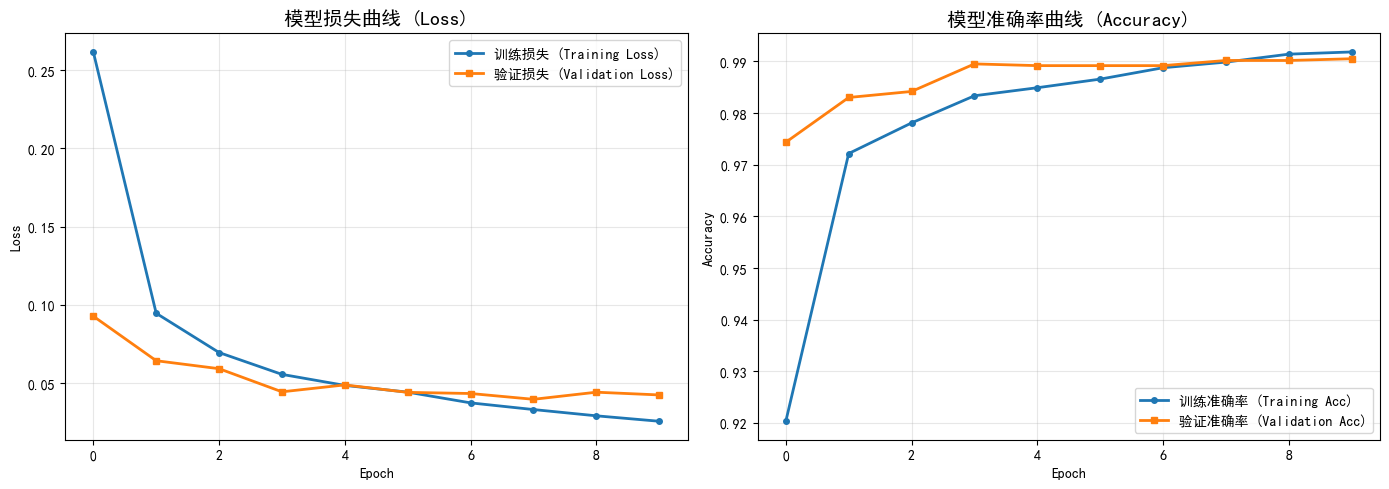

In [115]:
# ========== 7.2 绘制训练曲线 ==========

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# —— Loss 曲线 ——
ax1.plot(history.history['loss'], 'o-', label='训练损失 (Training Loss)', lw=2, ms=4)
ax1.plot(history.history['val_loss'], 's-', label='验证损失 (Validation Loss)', lw=2, ms=4)
ax1.set_title('模型损失曲线 (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# —— Accuracy 曲线 ——
ax2.plot(history.history['accuracy'], 'o-', label='训练准确率 (Training Acc)', lw=2, ms=4)
ax2.plot(history.history['val_accuracy'], 's-', label='验证准确率 (Validation Acc)', lw=2, ms=4)
ax2.set_title('模型准确率曲线 (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. 模型评估

在**测试集**（模型从未见过的数据）上评估泛化能力。使用两个互补的指标：
- **混淆矩阵**：直观展示每类数字被预测为什么
- **分类报告**：精确率（Precision）、召回率（Recall）、F1-Score

In [116]:
# ========== 8.1 测试集评估 ==========

# evaluate() 返回 [loss, accuracy]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"{'='*55}")
print(f"  测试集 Loss:      {test_loss:.4f}")
print(f"  测试集 Accuracy:   {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*55}")

# 获取全部 10000 张测试图片的预测结果
# predict() 返回 (10000, 10) — 每张图 10 个类别的概率
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)  # 取概率最大的类别索引

  测试集 Loss:      0.0270
  测试集 Accuracy:   0.9916  (99.16%)


### 8.2 混淆矩阵

|  | 含义 |
|--|------|
| **对角线** | 预测正确的样本数 |
| **非对角线** | 被误判为其他数字的样本数 |

> 对角线上的数字越大、颜色越深 → 分类效果越好。非对角线上的数字代表常见的误判模式。

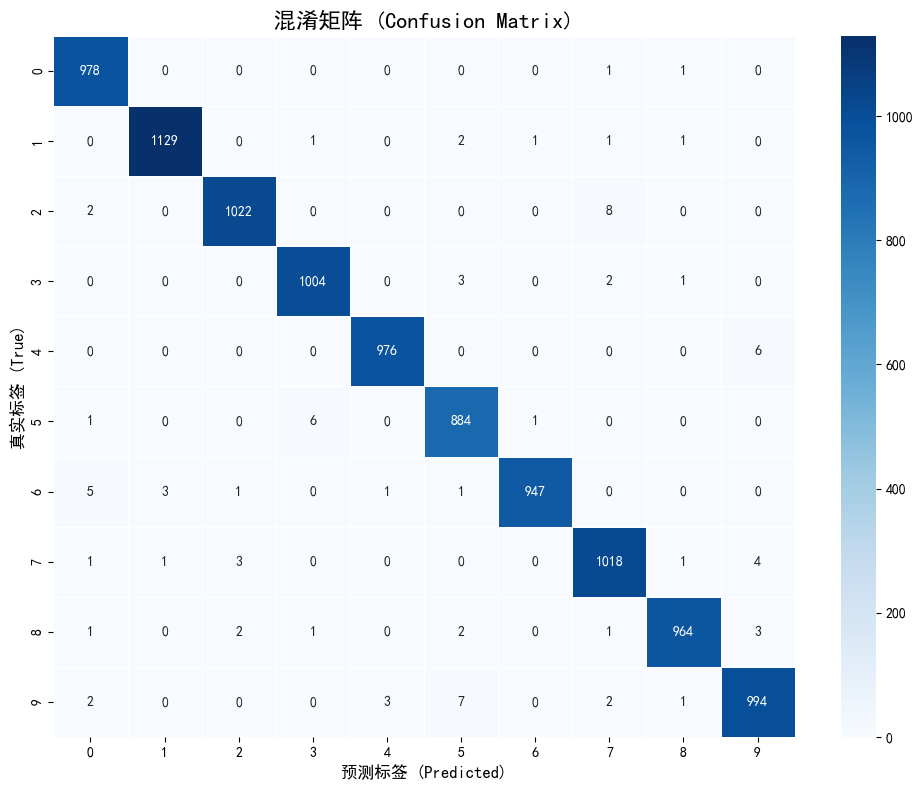


各类别识别准确率:
数字     正确/总数        准确率        状态
----------------------------------------
0      978/980          99.8%     ✓ 正常
1      1129/1135         99.5%     ✓ 正常
2      1022/1032         99.0%     ✓ 正常
3      1004/1010         99.4%     ✓ 正常
4      976/982          99.4%     ✓ 正常
5      884/892          99.1%     ✓ 正常
6      947/958          98.9%     ✓ 正常
7      1018/1028         99.0%     ✓ 正常
8      964/974          99.0%     ✓ 正常
9      994/1009         98.5%     ✓ 正常


In [117]:
# ========== 8.2 混淆矩阵 ==========

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, linecolor='white')
plt.title('混淆矩阵 (Confusion Matrix)', fontsize=16, fontweight='bold')
plt.xlabel('预测标签 (Predicted)', fontsize=12)
plt.ylabel('真实标签 (True)', fontsize=12)
plt.tight_layout()
plt.show()

# 打印每个数字的单独准确率
print("\n各类别识别准确率:")
print(f"{'数字':<6} {'正确/总数':<12} {'准确率':<10} {'状态'}")
print("-" * 40)
for i in range(10):
    tp = cm[i, i]           # 对角线 = 正确预测数
    total = cm[i, :].sum()  # 该类别总样本数
    rate = tp / total * 100
    status = '⚠️ 偏低' if rate < 97 else '✓ 正常'
    print(f"{i:<6} {tp}/{total:<11} {rate:5.1f}%     {status}")

### 8.3 分类报告

| 指标 | 公式 | 含义 |
|------|------|------|
| Precision（精确率） | TP / (TP + FP) | 预测为某类中真正正确的比例 |
| Recall（召回率） | TP / (TP + FN) | 某类真实样本中被正确识别的比例 |
| F1-Score | 2 × P × R / (P + R) | 精确率和召回率的调和平均 |

> 在多分类中，`macro avg` 对所有类别取简单平均，`weighted avg` 按样本数加权平均。

In [118]:
# ========== 8.3 分类报告 ==========

print("分类报告 (Classification Report):")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=[str(i) for i in range(10)]
))

分类报告 (Classification Report):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



---
## 9. 预测验证与错误分析

随机抽取测试样本，对比真实标签和预测结果。预测正确的用**绿色**标注，错误的用**红色**。

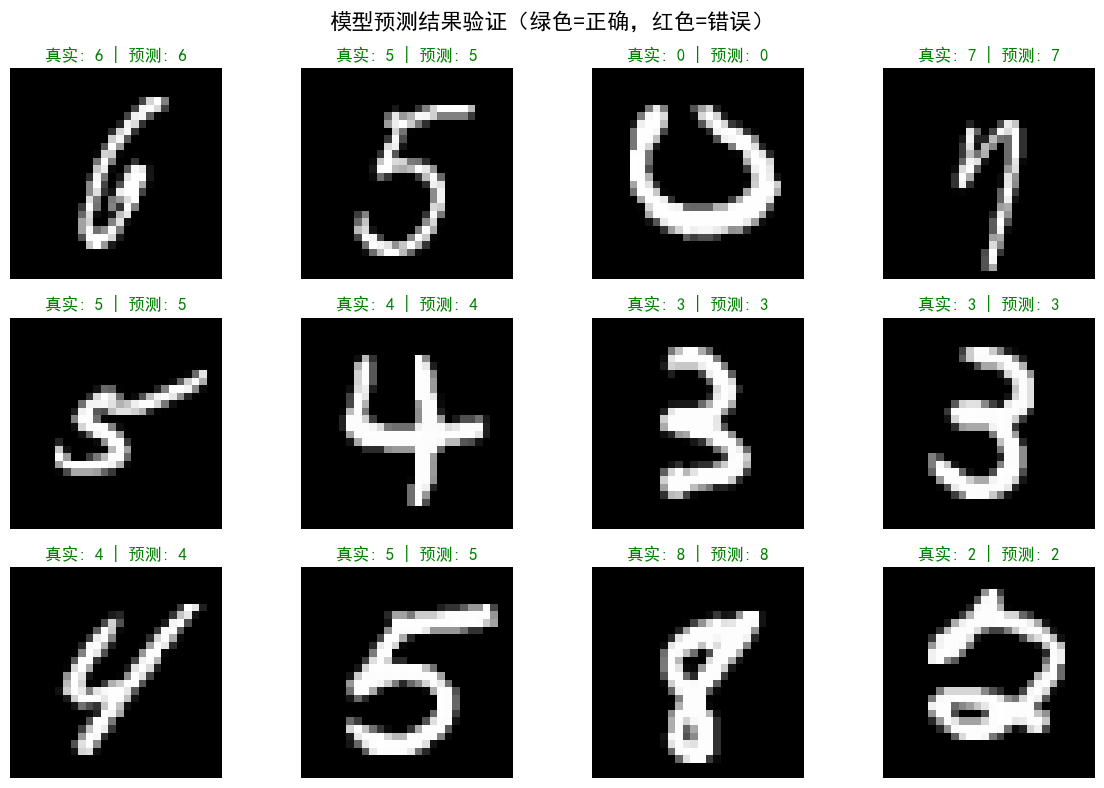

In [119]:
# ========== 9.1 随机预测验证 ==========

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
fig.suptitle('模型预测结果验证（绿色=正确，红色=错误）', fontsize=16, fontweight='bold')

sample_indices = np.random.choice(len(X_test), 12, replace=False)

for i, ax in enumerate(axes.flat):
    idx = sample_indices[i]
    is_correct = (y_test[idx] == y_pred[idx])
    color = 'green' if is_correct else 'red'
    
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'真实: {y_test[idx]} | 预测: {y_pred[idx]}',
                 color=color, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9.2 错误案例分析

找出所有预测错误的样本，展示前 9 个。观察模型在哪些数字之间容易混淆
（常见错误模式如：4↔9、3↔8↔5、2↔7 等）。

测试集错误: 84 / 10000 (0.84%)

最常见的误判模式 (真实→预测):
  2 → 7: 8 次
  9 → 5: 7 次
  5 → 3: 6 次
  4 → 9: 6 次
  6 → 0: 5 次


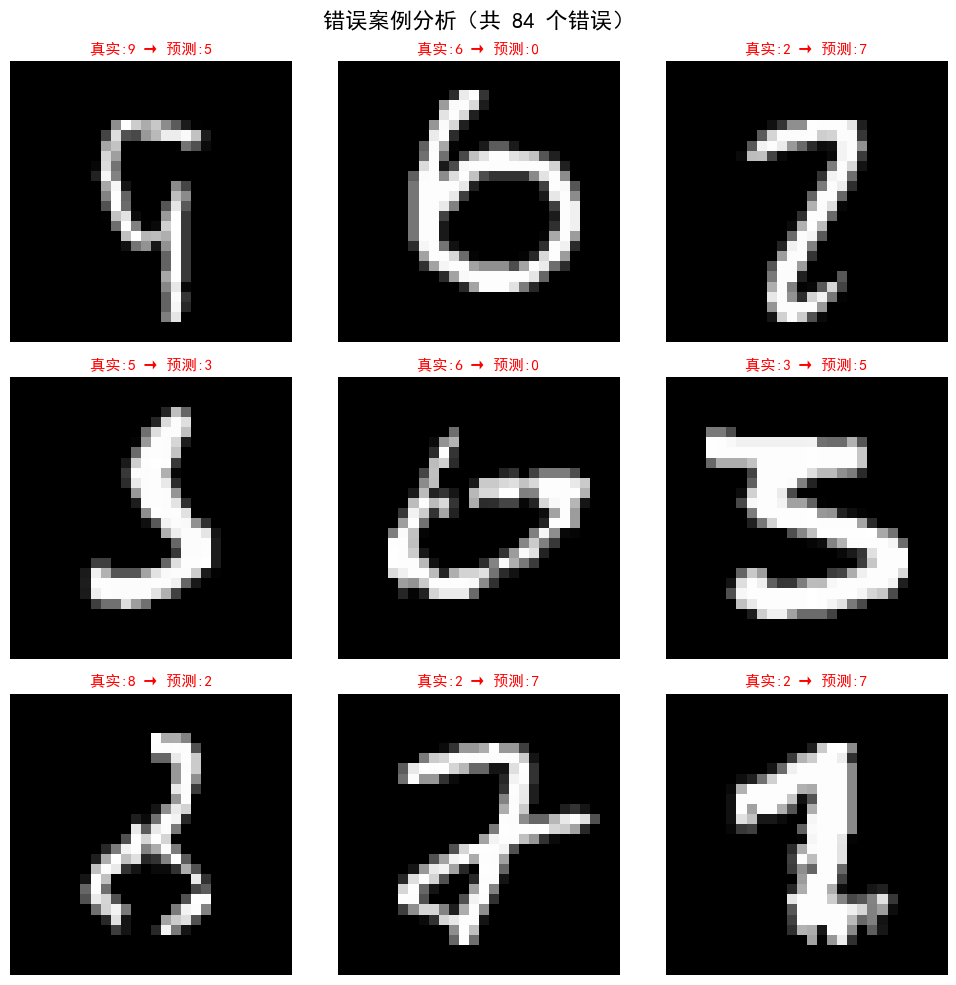

In [120]:
# ========== 9.2 错误案例分析 ==========

error_indices = np.where(y_pred != y_test)[0]
error_count = len(error_indices)
error_rate = error_count / len(y_test) * 100

print(f"测试集错误: {error_count} / {len(y_test)} ({error_rate:.2f}%)")

# 统计最常见的误判模式
if error_count > 0:
    error_pairs = list(zip(y_test[error_indices], y_pred[error_indices]))
    from collections import Counter
    top_errors = Counter(error_pairs).most_common(5)
    print("\n最常见的误判模式 (真实→预测):")
    for (true, pred), count in top_errors:
        print(f"  {true} → {pred}: {count} 次")

# 展示前 9 个错误案例
n_show = min(9, error_count)
if n_show > 0:
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f'错误案例分析（共 {error_count} 个错误）', fontsize=16, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < n_show:
            idx = error_indices[i]
            ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
            ax.set_title(f'真实:{y_test[idx]} → 预测:{y_pred[idx]}',
                        color='red', fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

> **❓ 思考**：为什么 4↔9、3↔8 是经典误判？  
> **答**：4 和 9 在顶部都有开口，3 和 8 的曲线结构相似。
> 此外，MNIST 数据本身就有一些人眼也难以分辨的模棱两可样本。
> 在调参实验区可以尝试**数据增强**，让模型见过更多变形样本，提升鲁棒性。

---
## 10. 保存模型

训练完成后，将模型保存为两种格式：
- **`.h5`**：Keras 原生格式，可被 TensorFlow 直接加载
- **`.onnx`**：ONNX 通用格式，可被 ONNX Runtime 加载（用于 GUI 上位机，避免 TensorFlow DLL 冲突）

In [121]:
# ========== 10.1 保存 H5 模型 ==========

MODEL_PATH = 'mnist_cnn.h5'
model.save(MODEL_PATH)

print(f"✅ H5 模型已保存: {os.path.abspath(MODEL_PATH)}")
print(f"   文件大小: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

✅ H5 模型已保存: d:\Desktop\School Course\Grade 3-2\人工智能\code\神经网络回归预测与分类\code\mnist_cnn.h5
   文件大小: 2677.1 KB


In [122]:
# ========== 10.2 验证 H5 加载 ==========

loaded_model = keras.models.load_model(MODEL_PATH)
loaded_loss, loaded_acc = loaded_model.evaluate(X_test, y_test, verbose=0)

print(f"原始模型测试准确率: {test_acc:.4f}")
print(f"加载模型测试准确率: {loaded_acc:.4f}")
if abs(test_acc - loaded_acc) < 1e-4:
    print("✅ 保存/加载一致，模型完整性验证通过")
else:
    print("⚠️ 准确率不一致！请检查保存过程")

原始模型测试准确率: 0.9916
加载模型测试准确率: 0.9916
✅ 保存/加载一致，模型完整性验证通过


In [123]:
# ========== 10.3 转换为 ONNX 格式 ==========
# ONNX Runtime 作为推理引擎，避免 PySide6 与 TensorFlow 的 DLL 加载冲突

try:
    import tf2onnx
    
    # 定义模型输入规格
    input_signature = (tf.TensorSpec((None, 28, 28, 1), tf.float32, name='input'),)
    
    # 清除 output_names，避免新版 Keras 内部张量名导致 KeyError
    model.output_names = None
    
    # Keras -> ONNX 转换（用 output_path 直接写入文件，更稳定）
    onnx_path = 'mnist_cnn.onnx'
    model_proto, _ = tf2onnx.convert.from_keras(
        model, input_signature=input_signature, opset=13,
        output_path=onnx_path
    )
    
    print(f"✅ ONNX 模型已保存: {onnx_path}")
    print(f"   文件大小: {os.path.getsize(onnx_path) / 1024:.0f} KB")
    print(f"   可使用 gui_app.py 加载进行手写识别")
    
except ImportError:
    print("⚠️ 未安装 tf2onnx")
    print("   安装: pip install tf2onnx")
    print("   或: GUI 启动时会自动从 .h5 转换")

✅ ONNX 模型已保存: mnist_cnn.onnx
   文件大小: 883 KB
   可使用 gui_app.py 加载进行手写识别


---
## 11. 🔧 调参实验区

以下是可以尝试调整的超参数，建议**每次只改一个参数**，观察对模型性能的影响。

| 参数 | 当前值 | 建议尝试 | 预期影响 |
|------|--------|----------|----------|
| 学习率 (lr) | 0.001 | 0.0001 / 0.01 | 太小收敛慢，太大震荡 |
| 卷积核数量 | (32, 64) | (16, 32) / (64, 128) | 多核→强表达力但更慢 |
| 卷积核大小 | 3×3 | 5×5 | 大核→更大感受野 |
| Dropout | 0.5 | 0.3 / 0.7 | 越大→正则化越强 |
| FC 神经元数 | 128 | 64 / 256 | 多→容量大但易过拟合 |
| Epoch 数 | 10 | 15 / 20 | 多→可能过拟合，需观察验证曲线 |
| Batch Size | 64 | 32 / 128 | 小→梯度噪声大；大→显存多 |
| 激活函数 | ReLU | LeakyReLU, ELU | 替代 ReLU，缓解"神经元死亡" |
| **数据增强** | 无 | rotation/zoom/shift | **最有效的提升手段！** |

### ⭐ 推荐实验：数据增强

数据增强是对训练数据做随机微小的变换（旋转、缩放、平移），让模型见过更多"变形"。
这是提升 MNIST 模型泛化能力最有效的方法——加入后准确率通常可达 99%+。

In [124]:
# ========== 11.1 数据增强实验 ==========

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 创建数据增强器：对每张训练图随机应用以下变换
datagen = ImageDataGenerator(
    rotation_range=10,        # 随机旋转 ±10°（手写数字有书写角度差异）
    width_shift_range=0.1,    # 随机水平平移 ±10%（数字位置不总是居中）
    height_shift_range=0.1,   # 随机垂直平移 ±10%
    zoom_range=0.1,           # 随机缩放 ±10%（数字大小差异）
)

# fit() 计算标准化所需的统计量（这里不需要标准化，但接口要求调用）
datagen.fit(X_train)

# 构建增强版模型（与原模型结构相同）
model_aug = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 使用 flow() 而非直接传数据——每次 epoch 都会生成新的随机变换
history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=15,                                # 数据增强下可以多训练几个 epoch
    validation_data=(X_valid, y_valid),
    verbose=1
)

# 评估
aug_loss, aug_acc = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"数据增强模型测试准确率: {aug_acc:.4f} ({aug_acc*100:.2f}%)")
print(f"原始模型测试准确率:     {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"提升: +{(aug_acc - test_acc)*100:.2f}%")
print(f"{'='*50}")

Epoch 1/15


f:\python\3.13.7\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8537 - loss: 0.4608 - val_accuracy: 0.9750 - val_loss: 0.0789
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9430 - loss: 0.1900 - val_accuracy: 0.9827 - val_loss: 0.0576
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9584 - loss: 0.1402 - val_accuracy: 0.9840 - val_loss: 0.0496
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9644 - loss: 0.1182 - val_accuracy: 0.9877 - val_loss: 0.0403
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9680 - loss: 0.1070 - val_accuracy: 0.9908 - val_loss: 0.0355
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9727 - loss: 0.0933 - val_accuracy: 0.9887 - val_loss: 0.0379
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9748 - loss: 0.0855 - val_accuracy: 0.9898 - val_loss: 0.0311
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9774 - loss: 0.0777 - val_accuracy: 0.99

---
## 12. 🤔 思考题

试着在代码中修改这些设计，观察结果变化。下面是参考答案（建议先自己做，再看答案）：

### 第 1 题：去掉 Dropout 会怎样？

> **参考答案**：训练集准确率会变得更高（甚至接近 100%），但验证集准确率反而可能下降，
> 两条曲线的差距会明显拉大。这就是典型的**过拟合**——模型把训练数据"背"下来了，
> 但遇到没见过的数字就懵了。Dropout 就像"故意让一部分神经元请假"，
> 迫使剩下的神经元学会独立工作，从而提高泛化能力。

### 第 2 题：用全连接替换卷积会怎样？

> **参考答案**：换成 `Dense(512)` 后，参数量会暴涨到 784×512 ≈ 40 万（仅第一层），
> 是原来整个模型的两倍。训练会非常慢，而且准确率反而更低——因为全连接层
> 看不到像素之间的空间关系。CNN 的"局部感受野"让每个神经元只看一小块区域，
> 这才是图像识别的关键，不是参数量多少的问题。

### 第 3 题：为什么自己的手写字比 MNIST 测试集难识别？

> **参考答案**：MNIST 测试集和训练集来自**同一批人、同一种书写方式**。
> 你写的数字笔画粗细、倾斜角度、用力习惯都和原始数据不同，这对模型来说是
> "陌生风格"。就像你练了一本字帖上的字，突然让你认另一个人的字——
> 能认个大概，但不一定对。这也是为什么 GUI 上位机里加了裁剪+居中+高斯模糊
> 这些预处理，尽量让你的字"看起来像"MNIST 训练数据。

### 第 4 题：Batch Size 调大调小有什么影响？

> **参考答案**：  
> - `batch_size=1`：每张图更新一次权重，梯度方向"东倒西歪"，训练很慢且不稳定  
> - `batch_size=32`：32 张图的平均梯度，方向更准，训练稳定且较快  
> - `batch_size=256`：256 张图一起算，梯度方向很准，但每步计算量大，
>   同样的 epoch 数实际看到的"不同梯度方向"变少了，可能需要更多 epoch  
> - 常用值是 32 或 64，在速度和稳定性之间取得平衡

### 第 5 题：验证集的 Loss 为什么跟着下降？

> **参考答案**：验证集不参与权重更新（不计算梯度），但模型在训练集上学到的
> 规律——比如"圆圈结构大概率是 8 或 0"——对验证集也适用。只要模型确实在学
> **可泛化的规则**而不是死记硬背，验证集的 Loss 就会跟着下降。如果哪天
> 验证 Loss 停止下降甚至反弹，说明模型开始"背答案"了，该停止了。

---
**下一步**：运行 `cd code && python gui_app.py` 启动手写识别上位机！